# Exercise 3

## Exercise 3.1

## Imports

In [5]:
from tensorflow.keras.datasets import mnist
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

## Function for training

In [6]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

def train(alpha):
  model = keras.Sequential([
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
  ])
  model.compile(optimizer=keras.optimizers.RMSprop(alpha),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  history=model.fit(train_images, train_labels,
            epochs=10,
            batch_size=128,
            validation_split=0.2)
  return history

## Function for plotting

In [7]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='train acc')
    axes[0].plot(history.history['val_accuracy'], label='val acc')
    axes[0].set_title(title + ' – Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'], label='train loss')
    axes[1].plot(history.history['val_loss'], label='val loss')
    axes[1].set_title(title + ' – Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## Run model with different learning rates and plot result

### $\alpha = 1.$

Epoch 1/10
375/375 [==============================] - 4s 8ms/step - loss: 501.6597 - accuracy: 0.2669 - val_loss: 2.7092 - val_accuracy: 0.2663
Epoch 2/10
375/375 [==============================] - 3s 7ms/step - loss: 2.6378 - accuracy: 0.2106 - val_loss: 2.3270 - val_accuracy: 0.1536
Epoch 3/10
375/375 [==============================] - 3s 8ms/step - loss: 2.7725 - accuracy: 0.1824 - val_loss: 2.4175 - val_accuracy: 0.1523
Epoch 4/10
375/375 [==============================] - 3s 7ms/step - loss: 2.5208 - accuracy: 0.1923 - val_loss: 2.3196 - val_accuracy: 0.1627
Epoch 5/10
375/375 [==============================] - 3s 7ms/step - loss: 2.5892 - accuracy: 0.1840 - val_loss: 2.7133 - val_accuracy: 0.2143
Epoch 6/10
375/375 [==============================] - 3s 8ms/step - loss: 2.4513 - accuracy: 0.1875 - val_loss: 2.2448 - val_accuracy: 0.2012
Epoch 7/10
375/375 [==============================] - 3s 7ms/step - loss: 2.4064 - accuracy: 0.1988 - val_loss: 2.2550 - val_accuracy: 0.2079
Epoc

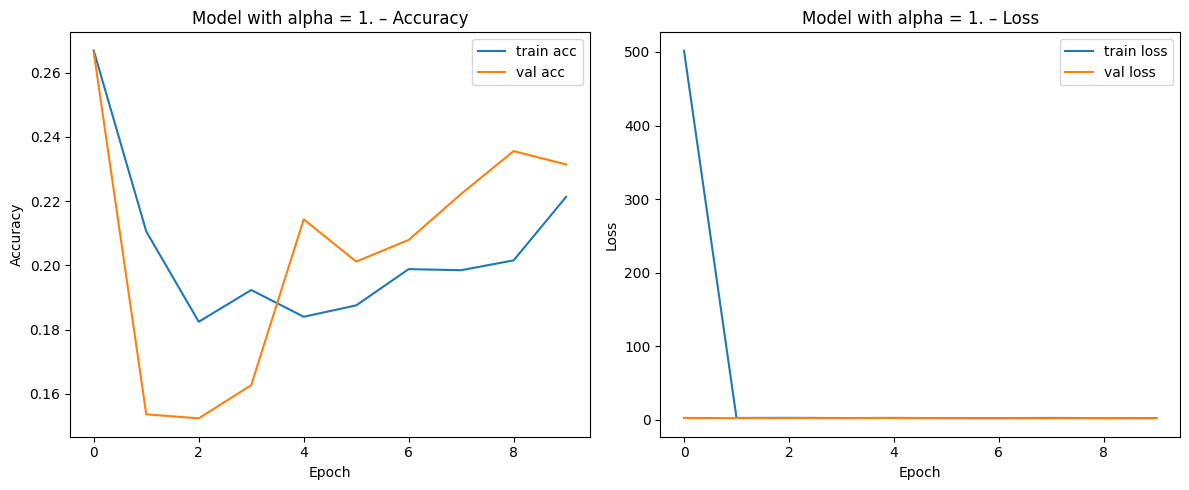

In [4]:
history = train(1.)
plot_history(history, "Model with alpha = 1.")

With $\alpha$ = 1.0, RMSprop produces updates that are far too large at the start of training, because the method expects a small base learning rate and then adjusts the effective step size internally. When $\alpha$ is this high, the internal scaling amplifies the updates instead of stabilizing them, causing the weights to blow up almost immediately. Once the weights become extremely large, many neurons end up in ranges where they no longer respond meaningfully to changes in input, and the softmax layer outputs extreme probabilities that push the loss toward zero for numerical reasons rather than real learning. This also explains why the accuracy stays low and unstable even though the loss appears to collapse. It is because the model is not improving, it has simply entered a numerically degenerate state where the loss no longer reflects actual performance.

### $\alpha = 0.5$

Epoch 1/10
375/375 [==============================] - 3s 8ms/step - loss: 165.8676 - accuracy: 0.3673 - val_loss: 2.0013 - val_accuracy: 0.2637
Epoch 2/10
375/375 [==============================] - 3s 7ms/step - loss: 2.3359 - accuracy: 0.2923 - val_loss: 2.0079 - val_accuracy: 0.2272
Epoch 3/10
375/375 [==============================] - 3s 8ms/step - loss: 2.2384 - accuracy: 0.2978 - val_loss: 1.9149 - val_accuracy: 0.3086
Epoch 4/10
375/375 [==============================] - 3s 8ms/step - loss: 2.3088 - accuracy: 0.3051 - val_loss: 13.0583 - val_accuracy: 0.2776
Epoch 5/10
375/375 [==============================] - 3s 8ms/step - loss: 2.1173 - accuracy: 0.3514 - val_loss: 1.7130 - val_accuracy: 0.3823
Epoch 6/10
375/375 [==============================] - 3s 8ms/step - loss: 2.1332 - accuracy: 0.3648 - val_loss: 1.7900 - val_accuracy: 0.3142
Epoch 7/10
375/375 [==============================] - 3s 8ms/step - loss: 2.0657 - accuracy: 0.3570 - val_loss: 1.7049 - val_accuracy: 0.3382
Epo

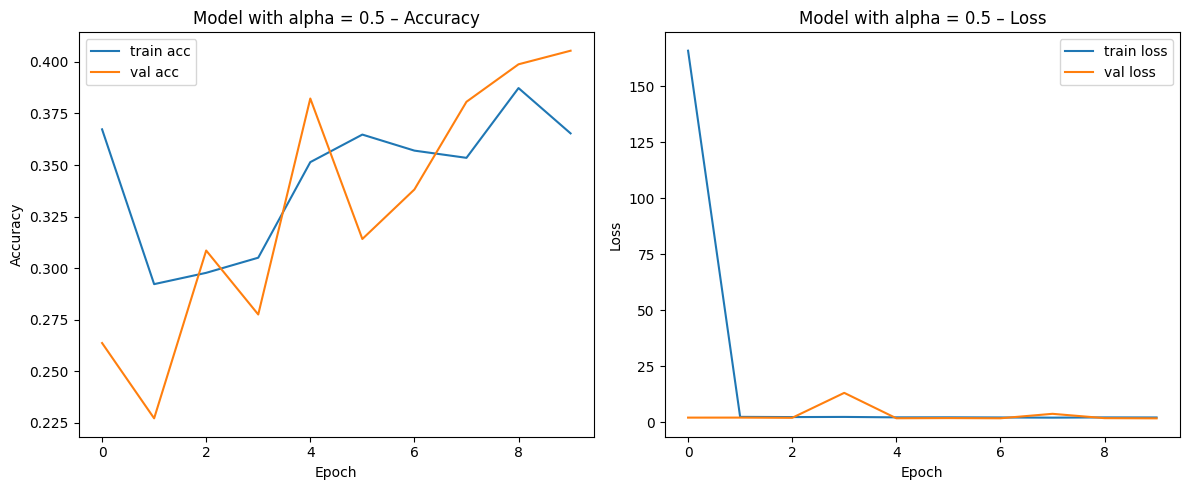

In [5]:
history = train(0.5)
plot_history(history, "Model with alpha = 0.5")

For $\alpha$ = 0.5 the training shows the same kind of instability as with $\alpha$ = 1, and although the accuracy is slightly higher the learning rate is still too large for RMSprop to enable meaningful learning.

### $\alpha = 0.1$

Epoch 1/10
375/375 [==============================] - 3s 8ms/step - loss: 7.1611 - accuracy: 0.8166 - val_loss: 0.6939 - val_accuracy: 0.8802
Epoch 2/10
375/375 [==============================] - 3s 8ms/step - loss: 0.6462 - accuracy: 0.8800 - val_loss: 0.5882 - val_accuracy: 0.8888
Epoch 3/10
375/375 [==============================] - 3s 8ms/step - loss: 0.5791 - accuracy: 0.8936 - val_loss: 0.5544 - val_accuracy: 0.8958
Epoch 4/10
375/375 [==============================] - 3s 7ms/step - loss: 0.5790 - accuracy: 0.8969 - val_loss: 0.5301 - val_accuracy: 0.8819
Epoch 5/10
375/375 [==============================] - 3s 8ms/step - loss: 0.5201 - accuracy: 0.9044 - val_loss: 0.7254 - val_accuracy: 0.8978
Epoch 6/10
375/375 [==============================] - 3s 8ms/step - loss: 0.5009 - accuracy: 0.9068 - val_loss: 0.5240 - val_accuracy: 0.9141
Epoch 7/10
375/375 [==============================] - 3s 7ms/step - loss: 0.4672 - accuracy: 0.9136 - val_loss: 0.5725 - val_accuracy: 0.9152
Epoch 

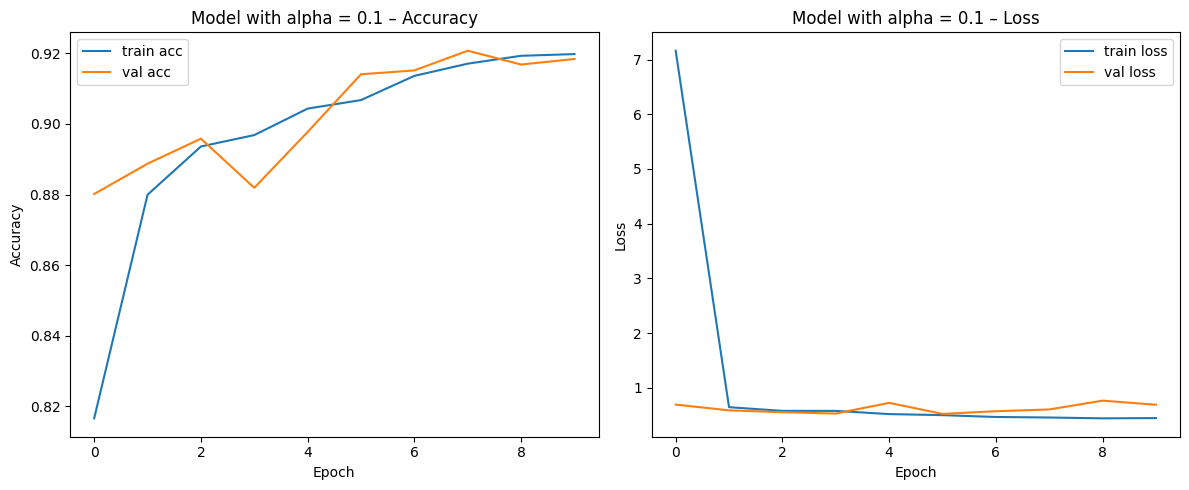

In [6]:
history = train(0.1)
plot_history(history, "Model with alpha = 0.1")

For $\alpha$ = 0.1 the training becomes genuinely stable, since the update steps are finally small enough for RMSprop to regulate them effectively rather than amplifying them. The accuracy curves rise steadily for both training and validation, which shows that the model is actually learning rather than drifting because of oversized updates. At the same time the loss decreases quickly at the start and then levels out in a smooth and consistent way, and the validation loss stays low without sudden spikes, which indicates that the parameter updates remain well‑behaved and do not push the network into extreme activation ranges. Overall this learning rate is still on the higher side but it is low enough for RMSprop to function as intended and produce meaningful improvements in both accuracy and loss.

### $\alpha = 0.01$

Epoch 1/10
375/375 [==============================] - 3s 8ms/step - loss: 0.3767 - accuracy: 0.9081 - val_loss: 0.1544 - val_accuracy: 0.9554
Epoch 2/10
375/375 [==============================] - 3s 8ms/step - loss: 0.1269 - accuracy: 0.9651 - val_loss: 0.1326 - val_accuracy: 0.9655
Epoch 3/10
375/375 [==============================] - 3s 8ms/step - loss: 0.1015 - accuracy: 0.9736 - val_loss: 0.1778 - val_accuracy: 0.9607
Epoch 4/10
375/375 [==============================] - 3s 8ms/step - loss: 0.0827 - accuracy: 0.9784 - val_loss: 0.1338 - val_accuracy: 0.9745
Epoch 5/10
375/375 [==============================] - 3s 7ms/step - loss: 0.0688 - accuracy: 0.9834 - val_loss: 0.1866 - val_accuracy: 0.9658
Epoch 6/10
375/375 [==============================] - 3s 7ms/step - loss: 0.0669 - accuracy: 0.9836 - val_loss: 0.1833 - val_accuracy: 0.9722
Epoch 7/10
375/375 [==============================] - 3s 7ms/step - loss: 0.0538 - accuracy: 0.9864 - val_loss: 0.2245 - val_accuracy: 0.9688
Epoch 

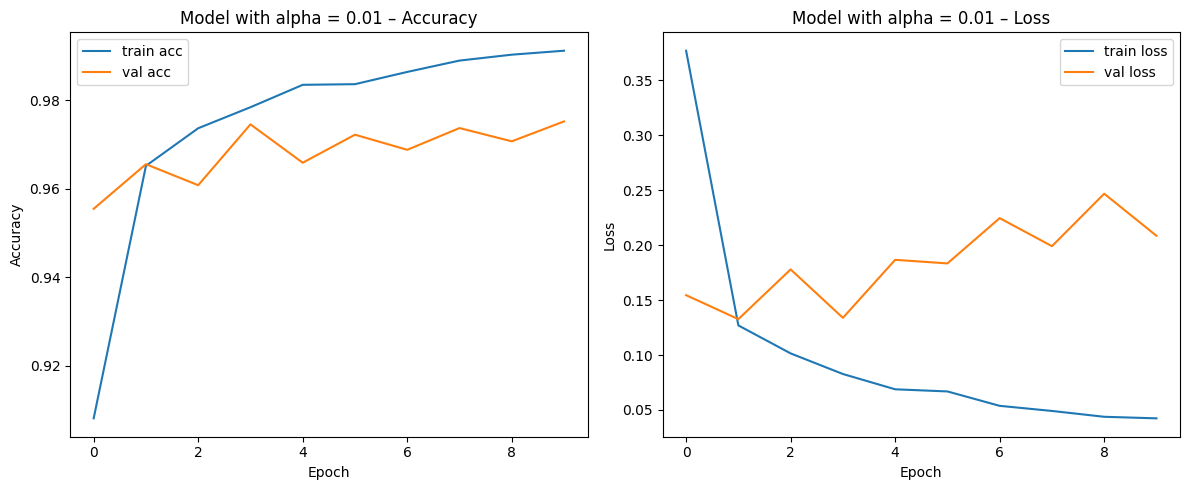

In [7]:
history = train(0.01)
plot_history(history, "Model with alpha = 0.01")

For $\alpha$ = 0.01 the training is clearly stable and the model learns effectively, but the validation loss begins to rise slightly even as the validation accuracy stays high. This pattern suggests that the learning rate is now small enough for RMSprop to guide the parameters smoothly toward a good solution, which is why the training accuracy climbs steadily and the training loss drops sharply. At the same time the gradual increase in validation loss indicates the early stages of overfitting, where the model continues to improve on the training data while becoming a bit less well calibrated on unseen data. The overall performance is still strong and consistent, but the divergence between training and validation loss shows that the model is starting to fit the training set more tightly than the validation set.

### $\alpha = 0.001$

Epoch 1/10
375/375 [==============================] - 3s 8ms/step - loss: 0.2946 - accuracy: 0.9146 - val_loss: 0.1532 - val_accuracy: 0.9553
Epoch 2/10
375/375 [==============================] - 3s 7ms/step - loss: 0.1236 - accuracy: 0.9631 - val_loss: 0.1075 - val_accuracy: 0.9701
Epoch 3/10
375/375 [==============================] - 3s 8ms/step - loss: 0.0811 - accuracy: 0.9758 - val_loss: 0.0878 - val_accuracy: 0.9743
Epoch 4/10
375/375 [==============================] - 3s 8ms/step - loss: 0.0584 - accuracy: 0.9829 - val_loss: 0.0805 - val_accuracy: 0.9756
Epoch 5/10
375/375 [==============================] - 3s 8ms/step - loss: 0.0435 - accuracy: 0.9879 - val_loss: 0.0845 - val_accuracy: 0.9756
Epoch 6/10
375/375 [==============================] - 3s 9ms/step - loss: 0.0332 - accuracy: 0.9900 - val_loss: 0.0751 - val_accuracy: 0.9780
Epoch 7/10
375/375 [==============================] - 3s 9ms/step - loss: 0.0246 - accuracy: 0.9928 - val_loss: 0.0803 - val_accuracy: 0.9772
Epoch 

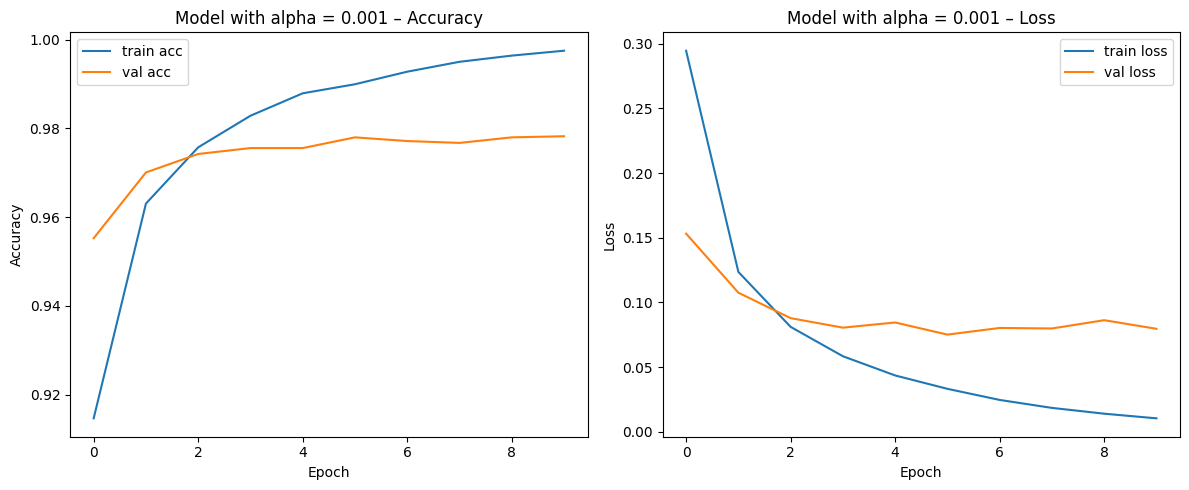

In [8]:
history = train(0.001)
plot_history(history, "Model with alpha = 0.001")

For $\alpha$ = 0.001 the training and validation curves both converge in a way that shows the model has reached a stable regime, even though they settle at slightly different levels. The training accuracy continues upward until it is almost perfect, while the validation accuracy levels off at a high and consistent value, which is exactly what you expect when the model is learning well but still fits the training data a bit more tightly. The loss curves show the same pattern of convergence, with training loss decreasing smoothly and validation loss dropping early and then fluctuating around a low plateau, which indicates that the model has reached a point where both sets of curves stabilize rather than drifting apart. This behaviour reflects a learning rate that is small enough for RMSprop to refine the parameters carefully, producing strong generalization while still showing the natural gap that appears when a model converges on training and validation data with different levels of exposure.

### Summary

Overall the results show that lowering $\alpha$ gradually leads to more stable training, smoother convergence and better generalization, since RMSprop performs best when the learning rate is small enough for its adaptive updates to dominate rather than being overwhelmed by large initial steps.

## Exercise 3.2

### Train the very small model

In [8]:
model = keras.Sequential([layers.Dense(10, activation='softmax')])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history_small_model = model.fit(
    train_images, train_labels,
    epochs=50,
    batch_size=128,
    validation_split=0.2)

Epoch 1/50
375/375 [==============================] - 1s 2ms/step - loss: 0.6702 - accuracy: 0.8366 - val_loss: 0.3600 - val_accuracy: 0.9064
Epoch 2/50
375/375 [==============================] - 1s 2ms/step - loss: 0.3536 - accuracy: 0.9028 - val_loss: 0.3108 - val_accuracy: 0.9128
Epoch 3/50
375/375 [==============================] - 1s 1ms/step - loss: 0.3181 - accuracy: 0.9114 - val_loss: 0.2930 - val_accuracy: 0.9188
Epoch 4/50
375/375 [==============================] - 1s 2ms/step - loss: 0.3020 - accuracy: 0.9164 - val_loss: 0.2839 - val_accuracy: 0.9210
Epoch 5/50
375/375 [==============================] - 1s 2ms/step - loss: 0.2923 - accuracy: 0.9184 - val_loss: 0.2779 - val_accuracy: 0.9228
Epoch 6/50
375/375 [==============================] - 1s 2ms/step - loss: 0.2857 - accuracy: 0.9199 - val_loss: 0.2741 - val_accuracy: 0.9248
Epoch 7/50
375/375 [==============================] - 1s 2ms/step - loss: 0.2803 - accuracy: 0.9216 - val_loss: 0.2719 - val_accuracy: 0.9255
Epoch 

### Plot the accuracy and loss

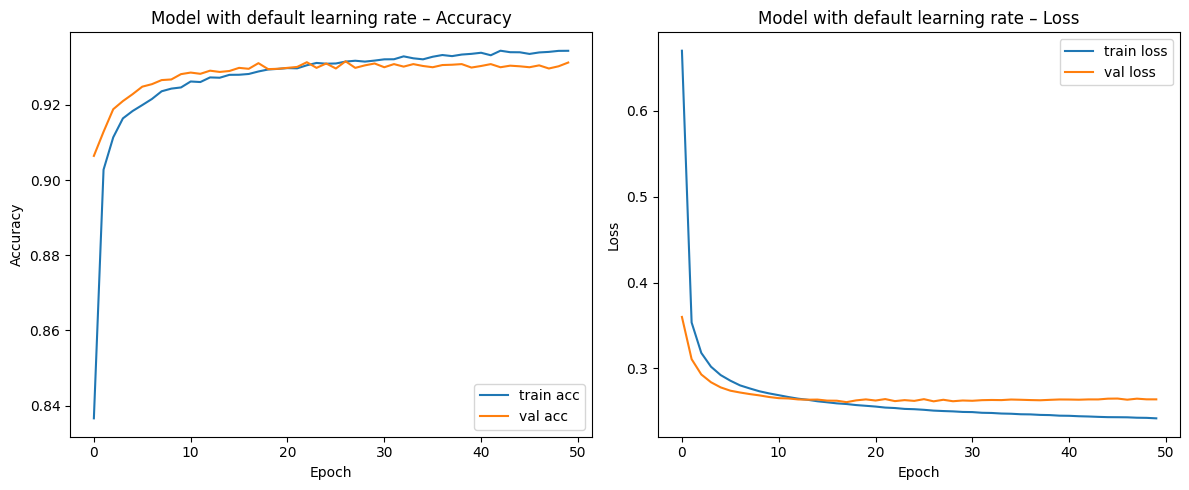

In [9]:
plot_history(history_small_model, "Model with default learning rate")

The small logistic regression model shows stable training behaviour, with both training and validation loss decreasing over time and converging toward similar levels. There is no sharp minimum in the validation loss, and the curve instead flattens out, which indicates that the model has limited capacity and therefore only exhibits very mild overfitting. After roughly ten epochs the validation loss stops improving, showing that additional training offers little further benefit.

## Exercise 3.3

### Train the complex model

In [10]:
model = keras.Sequential([
  layers.Dense(96, activation='relu'),
  layers.Dense(96, activation='relu'),
  layers.Dense(10, activation='softmax'),
])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history_large_model = model.fit(
    train_images, train_labels,
    epochs=50,
    batch_size=128,
    validation_split=0.2)

Epoch 1/50
375/375 [==============================] - 2s 3ms/step - loss: 0.3686 - accuracy: 0.8946 - val_loss: 0.1880 - val_accuracy: 0.9467
Epoch 2/50
375/375 [==============================] - 1s 3ms/step - loss: 0.1676 - accuracy: 0.9512 - val_loss: 0.1458 - val_accuracy: 0.9562
Epoch 3/50
375/375 [==============================] - 1s 3ms/step - loss: 0.1166 - accuracy: 0.9652 - val_loss: 0.1158 - val_accuracy: 0.9651
Epoch 4/50
375/375 [==============================] - 1s 3ms/step - loss: 0.0884 - accuracy: 0.9741 - val_loss: 0.1083 - val_accuracy: 0.9682
Epoch 5/50
375/375 [==============================] - 1s 2ms/step - loss: 0.0712 - accuracy: 0.9788 - val_loss: 0.1024 - val_accuracy: 0.9706
Epoch 6/50
375/375 [==============================] - 1s 3ms/step - loss: 0.0578 - accuracy: 0.9825 - val_loss: 0.1073 - val_accuracy: 0.9694
Epoch 7/50
375/375 [==============================] - 1s 3ms/step - loss: 0.0482 - accuracy: 0.9849 - val_loss: 0.1008 - val_accuracy: 0.9714
Epoch 

### Plot the accuracy and loss

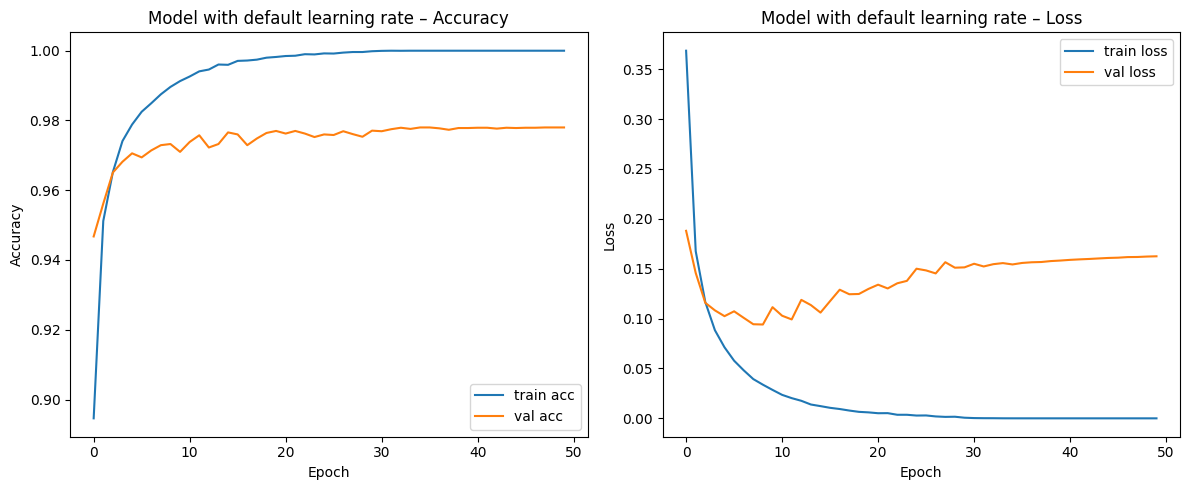

In [11]:
plot_history(history_large_model, "Model with default learning rate")

The larger model shows a clear overfitting pattern. The training accuracy quickly reaches almost 100% and the training loss approaches zero, while the validation loss decreases at first but then begins to rise and fluctuate. This indicates that the model has enough capacity to fit the training data extremely well, but after a certain point (around 10 epochs) it starts to memorize rather than generalize. The distinct minimum in the validation loss therefore marks the onset of overfitting, which is much more pronounced than in the smaller model.